UNDERSTAND PROBLEM:
Loan Lenders must accurately predict whether a loan will be repaid to minimize financial loss. By predicting the loan status of every individual, lenders can identify behavioral patterns and risk factors. This is a challenging problem because many variables influence a borrower’s ability to pay, and "defaults" are much rarer than "successful payments" in the data.

Output: Approve / Reject -> Binary Classification (0 = Charged Off, 1 = Fully Paid).
Goal: Minimize Financial Risk 
Target: High Recall for Class 0 
Decision (business rule after prediction): risk is high → Reject, risk is low → Approve
Algorithm: Logistic Regression
Datasets:
1. Test: https://www.kaggle.com/datasets/zaurbegiev/my-dataset?resource=download&select=credit_test.csv
2. Train: https://www.kaggle.com/datasets/zaurbegiev/my-dataset?resource=download&select=credit_train.csv

Data Preparation for Logistic Regression

1. Clean and preprocess the data, handling missing values and outliers.
2. Select relevant features for the logistic regression model.
3. Encode categorical variables using techniques like one-hot encoding.
4. Scale continuous variables for better convergence during optimization.
5. Address class imbalance if present, using techniques like oversampling or undersampling.
6. Split the data into training and testing sets for model evaluation.
7. Check for multicollinearity and handle it if present.

1. Importing Libraries 

In [1]:
#pip install pandas numpy matplotlib seaborn scikit-learn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, precision_score, recall_score

In [141]:
train = pd.read_csv("credit_train.csv")
test = pd.read_csv("credit_test.csv")

train.head()


,Loan ID,Customer ID,Loan Status,Current Loan Amount,Term,Credit Score,Annual Income,Years in current job,Home Ownership,Purpose,Monthly Debt,Years of Credit History,Months since last delinquent,Number of Open Accounts,Number of Credit Problems,Current Credit Balance,Maximum Open Credit,Bankruptcies,Tax Liens
0,14dd8831-6af5-400b-83ec-68e61888a048,981165ec-3274-42f5-a3b4-d104041a9ca9,Fully Paid,445412.0,Short Term,709.0,1167493.0,8 years,Home Mortgage,Home Improvements,5214.74,17.2,NaN,6.0,1.0,228190.0,416746.0,1.0,0.0
1,4771cc26-131a-45db-b5aa-537ea4ba5342,2de017a3-2e01-49cb-a581-08169e83be29,Fully Paid,262328.0,Short Term,NaN,NaN,10+ years,Home Mortgage,Debt Consolidation,33295.98,21.1,8.0,35.0,0.0,229976.0,850784.0,0.0,0.0
2,4eed4e6a-aa2f-4c91-8651-ce984ee8fb26,5efb2b2b-bf11-4dfd-a572-3761a2694725,Fully Paid,99999999.0,Short Term,741.0,2231892.0,8 years,Own Home,Debt Consolidation,29200.53,14.9,29.0,18.0,1.0,297996.0,750090.0,0.0,0.0
3,77598f7b-32e7-4e3b-a6e5-06ba0d98fe8a,e777faab-98ae-45af-9a86-7ce5b33b1011,Fully Paid,347666.0,Long Term,721.0,806949.0,3 years,Own Home,Debt Consolidation,8741.90,12.0,NaN,9.0,0.0,256329.0,386958.0,0.0,0.0
4,d4062e70-befa-4995-8643-a0de73938182,81536ad9-5ccf-4eb8-befb-47a4d608658e,Fully Paid,176220.0,Short Term,NaN,NaN,5 years,Rent,Debt Consolidation,20639.70,6.1,NaN,15.0,0.0,253460.0,427174.0,0.0,0.0


In [142]:
train.info()
train.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100514 entries, 0 to 100513
Data columns (total 19 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   Loan ID                       100000 non-null  object 
 1   Customer ID                   100000 non-null  object 
 2   Loan Status                   100000 non-null  object 
 3   Current Loan Amount           100000 non-null  float64
 4   Term                          100000 non-null  object 
 5   Credit Score                  80846 non-null   float64
 6   Annual Income                 80846 non-null   float64
 7   Years in current job          95778 non-null   object 
 8   Home Ownership                100000 non-null  object 
 9   Purpose                       100000 non-null  object 
 10  Monthly Debt                  100000 non-null  float64
 11  Years of Credit History       100000 non-null  float64
 12  Months since last delinquent  46859 non-null

(100514, 19)

2. Data Wrangling: Cleaning the Dataset

In [143]:
train.isnull().sum()

Loan ID                           514
Customer ID                       514
Loan Status                       514
Current Loan Amount               514
Term                              514
Credit Score                    19668
Annual Income                   19668
Years in current job             4736
Home Ownership                    514
Purpose                           514
Monthly Debt                      514
Years of Credit History           514
Months since last delinquent    53655
Number of Open Accounts           514
Number of Credit Problems         514
Current Credit Balance            514
Maximum Open Credit               516
Bankruptcies                      718
Tax Liens                         524
dtype: int64

In [144]:
train['Current Loan Amount'] = train['Current Loan Amount'].fillna(train['Current Loan Amount'].mean())
train['Credit Score'] = train['Credit Score'].fillna(train['Credit Score'].median())

In [145]:
train.isnull().sum()

Loan ID                           514
Customer ID                       514
Loan Status                       514
Current Loan Amount                 0
Term                              514
Credit Score                        0
Annual Income                   19668
Years in current job             4736
Home Ownership                    514
Purpose                           514
Monthly Debt                      514
Years of Credit History           514
Months since last delinquent    53655
Number of Open Accounts           514
Number of Credit Problems         514
Current Credit Balance            514
Maximum Open Credit               516
Bankruptcies                      718
Tax Liens                         524
dtype: int64

In [146]:
train.dropna(inplace=True)

In [147]:
train.isnull().sum()

Loan ID                         0
Customer ID                     0
Loan Status                     0
Current Loan Amount             0
Term                            0
Credit Score                    0
Annual Income                   0
Years in current job            0
Home Ownership                  0
Purpose                         0
Monthly Debt                    0
Years of Credit History         0
Months since last delinquent    0
Number of Open Accounts         0
Number of Credit Problems       0
Current Credit Balance          0
Maximum Open Credit             0
Bankruptcies                    0
Tax Liens                       0
dtype: int64

In [148]:
train.shape

(36423, 19)

2.  Data Visualisation: Understanding Relationships

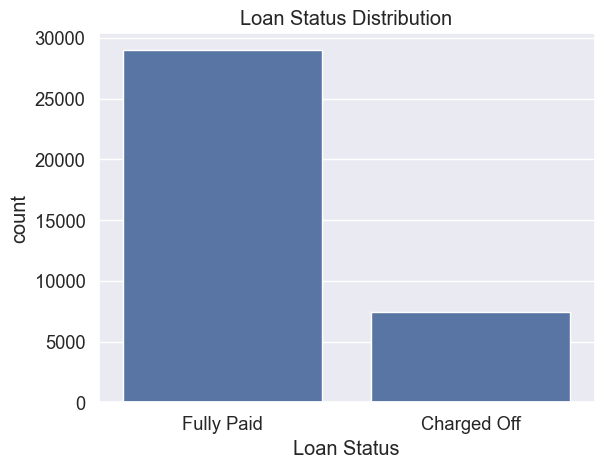

Loan Status
Fully Paid     0.795431
Charged Off    0.204569
Name: proportion, dtype: float64

In [149]:
#Target Distribution (Count Plot)

sns.countplot(x='Loan Status', data=train)
plt.title("Loan Status Distribution")
plt.show()

#counts how many times each category appears, converts counts into proportions (percentages)
train['Loan Status'].value_counts(normalize=True)
# Why it matter?
#If your classes are imbalanced = Accuracy alone becomes misleading
# need:
# resampling (SMOTE, undersampling)
# different metrics (F1-score, ROC-AUC)
# class weights in your model

# Our dataset is imbalanced, but not extremely bad. Model could lean toward predicting “Fully Paid”

In [150]:
#Correlation with Target (Bar Plot)
temp_df = train.copy()

le = LabelEncoder()
for col in temp_df.select_dtypes(include='object'):
    temp_df[col] = le.fit_transform(temp_df[col])

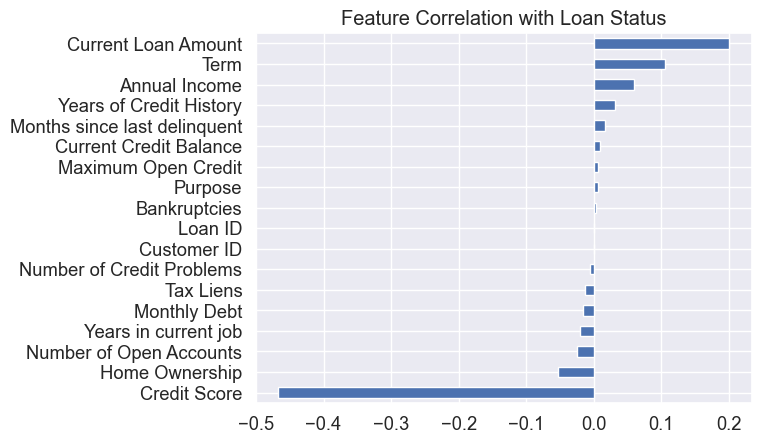

In [151]:
corr = temp_df.corr()

# correlation with target
target_corr = corr['Loan Status'].drop('Loan Status').sort_values()

target_corr.plot(kind='barh')
plt.title("Feature Correlation with Loan Status")
plt.show()

# Right side (+) → increases chance of Charged Off (1)
# Left side (–) → increases chance of Fully Paid (0)

Data Analysis

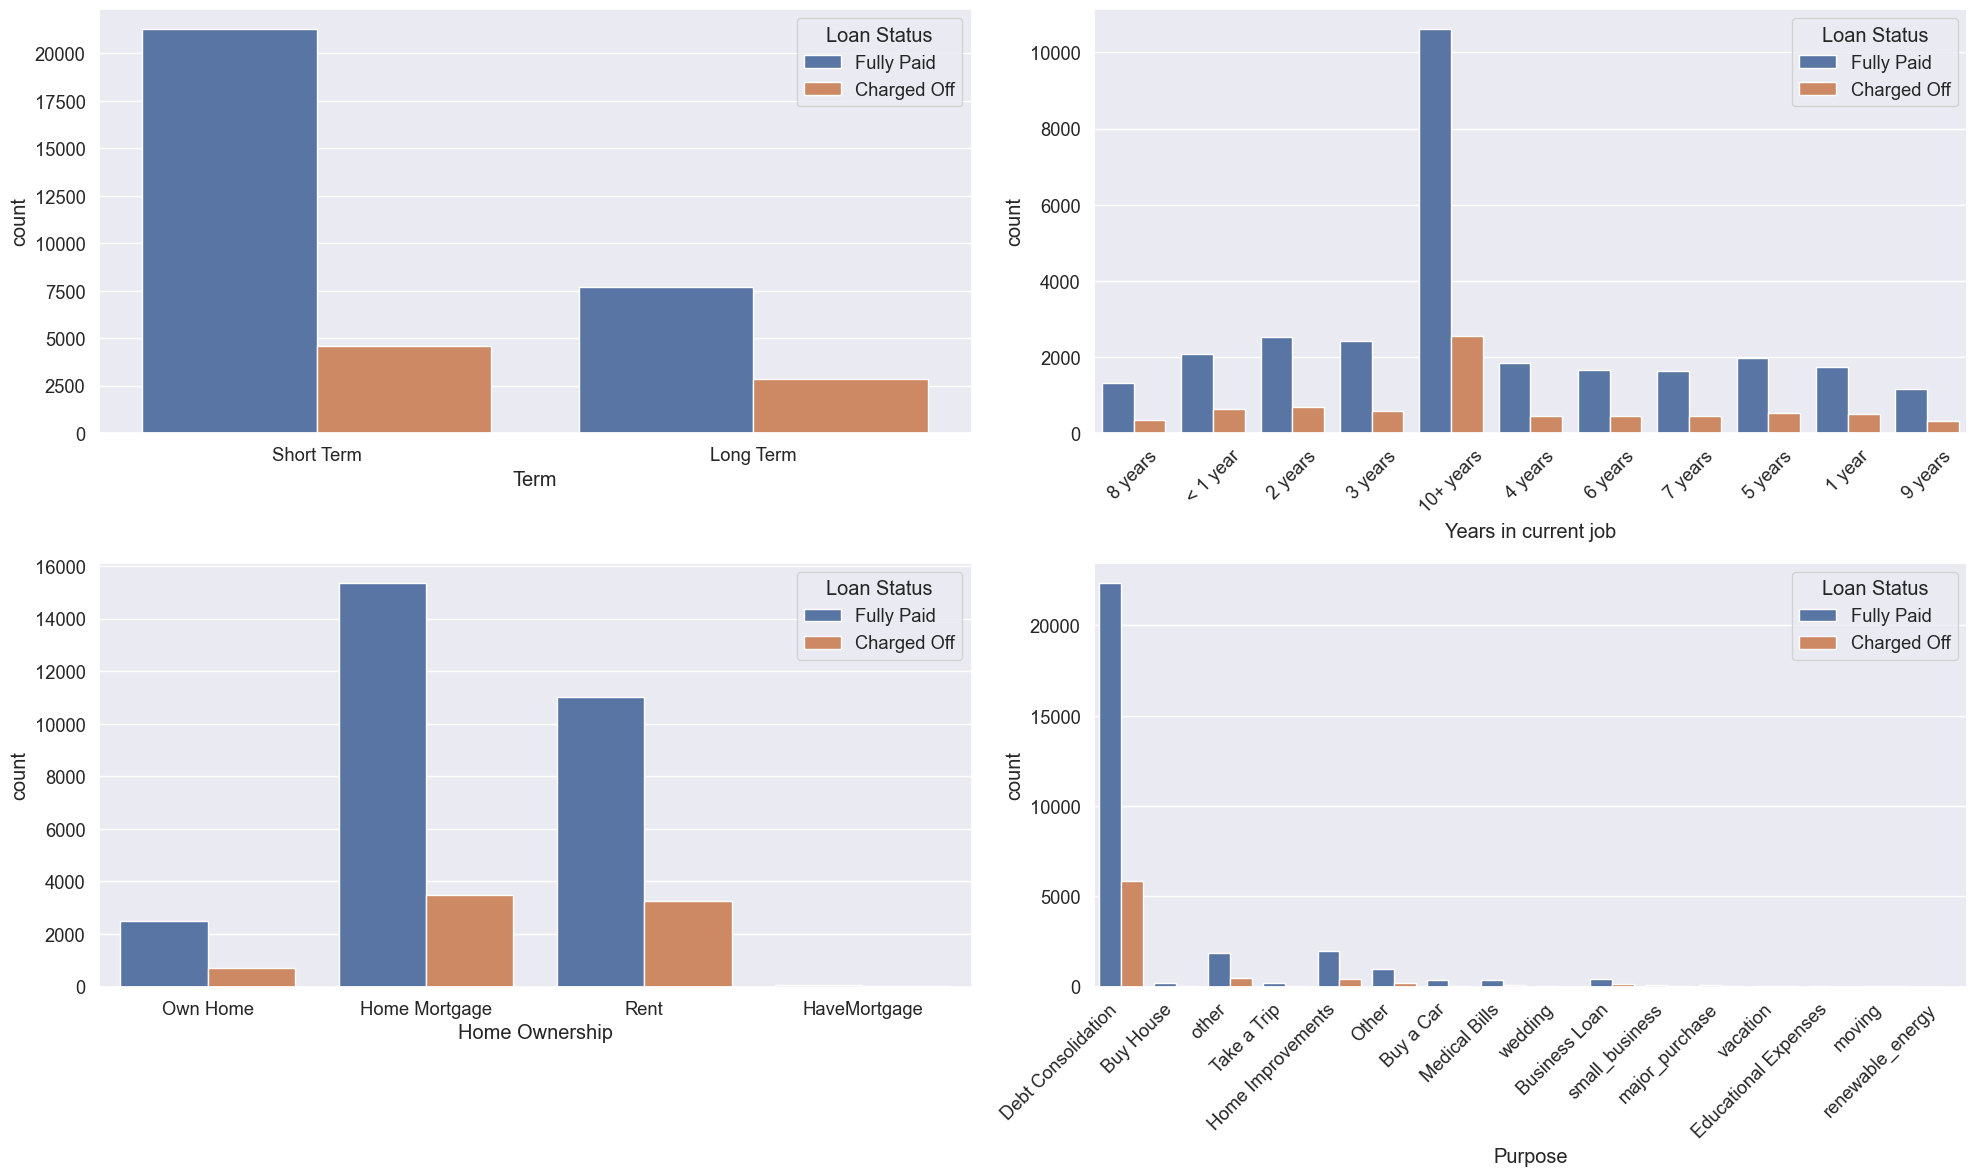

In [152]:
plt.figure(figsize=(20, 12)) # Slightly wider to give labels room
sns.set(font_scale=1.2) 

# Plot 1: Term
plt.subplot(221) # Changed to 2x2 grid for better spacing
sns.countplot(x='Term', hue='Loan Status', data=train)

# Plot 2: Years in current job (Fixed index to 222)
plt.subplot(222)
sns.countplot(x='Years in current job', hue='Loan Status', data=train)
plt.xticks(rotation=45) # Rotate labels so they don't overlap

# Plot 3: Home Ownership
plt.subplot(223)
sns.countplot(x='Home Ownership', hue='Loan Status', data=train)

# Plot 4: Purpose
plt.subplot(224)
sns.countplot(x='Purpose', hue='Loan Status', data=train)
plt.xticks(rotation=45, ha='right') # Rotate and align to the right

plt.tight_layout()
plt.show()

Replacing the variable values to numerical form & display the valyuecount
because: data in numerical form can prevent diturbamce in building the model

In [153]:
# This only changes the values you specify. 
# If the column contains other values not listed in your dictionar
# .replace() leaves them exactly as they are.

train['Loan Status'].replace('Fully Paid', 1, inplace=True)
train['Loan Status'].replace('Charged Off', 0, inplace=True)
train['Loan Status'].value_counts()

Loan Status
1    28972
0     7451
Name: count, dtype: int64

In [154]:
print(train['Term'].unique())

['Short Term' 'Long Term']


In [155]:

term_mapping = {
  'Short Term':1,
  'Long Term':0
}

train['Term'] = train['Term'].map(term_mapping)
train['Term'].value_counts()

Term
1    25855
0    10568
Name: count, dtype: int64

In [156]:
print(train['Years in current job'].unique())

['8 years' '< 1 year' '2 years' '3 years' '10+ years' '4 years' '6 years'
 '7 years' '5 years' '1 year' '9 years']


In [157]:
job_mapping = {
    '< 1 year': 0,
    '1 year': 1,
    '2 years': 2,
    '3 years': 3,
    '4 years': 4,
    '5 years': 5,
    '6 years': 6,
    '7 years': 7,
    '8 years': 8,
    '9 years': 9,
    '10+ years': 10
}

train['Years in current job'] = train['Years in current job'].map(job_mapping)
train['Years in current job'].value_counts()

Years in current job
10    13149
2      3225
3      2997
0      2699
5      2487
4      2286
1      2247
6      2109
7      2082
8      1675
9      1467
Name: count, dtype: int64

In [158]:
print(train['Home Ownership'].unique())

['Own Home' 'Home Mortgage' 'Rent' 'HaveMortgage']


In [159]:
home_mapping = {
    'Home Mortgage': 0,
    'Own Home': 1,
    'Rent': 2,
    'HaveMortgage': 3,
}

train['Home Ownership'] = train['Home Ownership'].map(home_mapping)
train['Home Ownership'].value_counts()

Home Ownership
0    18831
2    14300
1     3205
3       87
Name: count, dtype: int64

In [160]:
print(train['Purpose'].unique())

['Debt Consolidation' 'Buy House' 'other' 'Take a Trip'
 'Home Improvements' 'Other' 'Buy a Car' 'Medical Bills' 'wedding'
 'Business Loan' 'small_business' 'major_purchase' 'vacation'
 'Educational Expenses' 'moving' 'renewable_energy']


In [161]:
purpose_mapping = {
    'Debt Consolidation': 0,
    'Home Improvements': 1,
    'other': 2,
    'Other': 2, # Grouping 'other' and 'Other' together
    'Business Loan': 3,
    'small_business': 3, # Grouping business types
    'Buy a Car': 4,
    'Medical Bills': 5,
    'Buy House': 6,
    'Take a Trip': 7,
    'vacation': 7, # Grouping travel
    'wedding': 8,
    'major_purchase': 9,
    'Educational Expenses': 10,
    'moving': 11,
    'renewable_energy': 12
}

train['Purpose'] = train['Purpose'].map(purpose_mapping)

train['Purpose'].value_counts()

Purpose
0     28202
2      3463
1      2409
3       707
5       444
4       428
6       263
7       260
9       116
11       55
8        39
10       33
12        4
Name: count, dtype: int64

In [ ]:
#FInal data frameeeeeeeeee
#All values have been change to numerical data
train.head()


,Loan ID,Customer ID,Loan Status,Current Loan Amount,Term,Credit Score,Annual Income,Years in current job,Home Ownership,Purpose,Monthly Debt,Years of Credit History,Months since last delinquent,Number of Open Accounts,Number of Credit Problems,Current Credit Balance,Maximum Open Credit,Bankruptcies,Tax Liens
2,4eed4e6a-aa2f-4c91-8651-ce984ee8fb26,5efb2b2b-bf11-4dfd-a572-3761a2694725,1,99999999.0,1,741.0,2231892.0,8,1,0,29200.53,14.9,29.0,18.0,1.0,297996.0,750090.0,0.0,0.0
6,273581de-85d8-4332-81a5-19b04ce68666,90a75dde-34d5-419c-90dc-1e58b04b3e35,1,217646.0,1,730.0,1184194.0,0,0,0,10855.08,19.6,10.0,13.0,1.0,122170.0,272052.0,1.0,0.0
8,8af915d9-9e91-44a0-b5a2-564a45c12089,af534dea-d27e-4fd6-9de8-efaa52a78ec0,1,548746.0,1,678.0,2559110.0,2,2,0,18660.28,22.6,33.0,4.0,0.0,437171.0,555038.0,0.0,0.0
10,32c2e48f-1ba8-45e0-a530-9a6622c18d9c,0de7bcdb-ebf4-4608-ba39-05f083f855b6,1,99999999.0,1,728.0,714628.0,3,2,0,11851.06,16.0,76.0,16.0,0.0,203965.0,289784.0,0.0,0.0
12,403d7235-0284-4bb6-919a-09402fecbf7b,11581f68-de3c-49d8-80d9-22268ebb323b,1,99999999.0,1,740.0,776188.0,0,1,0,11578.22,8.5,25.0,6.0,0.0,134083.0,220220.0,0.0,0.0


Importing Packages for classification algorithms

In [181]:
#splitting data for model to study (train) and to test accuracy (test)
from sklearn.model_selection import train_test_split
#mathematical algorithm that will learn the patterns in data.
from sklearn.linear_model import LogisticRegression
# tell you how many loans the model predicted correctly.
from sklearn import metrics
from sklearn.metrics import classification_report


Splitting the dATA  INTO TRAIN AND TEST SET

In [170]:
train.shape

(36423, 19)

In [172]:
train.columns

Index(['Loan ID', 'Customer ID', 'Loan Status', 'Current Loan Amount', 'Term',
       'Credit Score', 'Annual Income', 'Years in current job',
       'Home Ownership', 'Purpose', 'Monthly Debt', 'Years of Credit History',
       'Months since last delinquent', 'Number of Open Accounts',
       'Number of Credit Problems', 'Current Credit Balance',
       'Maximum Open Credit', 'Bankruptcies', 'Tax Liens'],
      dtype='object')

In [174]:
#the clue
#independent variable
X = train.iloc[:, 3:].values 

#the answer
#dependant variable and predicting
y = train.iloc[:, 2].values

In [175]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)

Logistic Regression (LR)


-Logistic regression is a supervised learning classification algorithm used to predict the probability of a target variable.
-Mathematuically, a logistic regression model predicts P(Y=1) as a function of X. It is one of the simplest ML algo that can be used for various classification problems such as spam detection, cancer detection, loan, etc.
-sigmoid function, sig(t) = 1/(1 + e^-t)

In [188]:
model = LogisticRegression(class_weight='balanced', max_iter=1000)
model.fit(X_train, y_train)

lr_prediction = model.predict(X_test)
print('Logistioc regression accuracy = ', metrics.accuracy_score(lr_prediction, y_test))

#Initially, if i do only model = LogisticRegression(),i get accuracy 84% and recall 24%, but it is most likely bias because the data for "Loan Status" is imbalanced which is more to "Fully Paid"
#Then, if i do only model = LogisticRegression(class_weight='balanced', max_iter=1000) to get the weight balance,i get accuracy 64% and recall 60%"


Logistioc regression accuracy =  0.6736524206094994


In [189]:
print(lr_prediction[1])
print(y_test[1])

#1 shown that for that specific person in your test set, the model correctly predicted they would fully pay their loan.
#if class_weight='balanced', i will get 01

0
1


In [190]:
print("y_predicted",lr_prediction)
print("y_test",y_test)

y_predicted [1 0 0 ... 0 0 1]
y_test [1 1 1 ... 0 1 1]


In [192]:
print(classification_report(y_test, lr_prediction))

# Is this "Good Enough"?
# In the industry, a 60% recall for defaults is a very solid starting point for a simple Logistic Regression.
# To get even better results (higher accuracy and higher recall), 
# data scientists usually move to more complex models like Random Forest or XGBoost.

              precision    recall  f1-score   support

           0       0.34      0.60      0.43      2244
           1       0.87      0.69      0.77      8683

    accuracy                           0.67     10927
   macro avg       0.60      0.65      0.60     10927
weighted avg       0.76      0.67      0.70     10927



The model currently operates with a conservative risk profile. By prioritizing the detection of defaults (60% Recall), the model necessarily flags a higher volume of applicants for review. While this results in a Precision of 34%—meaning some creditworthy customers are incorrectly flagged—it minimizes the bank's exposure to catastrophic loan losses.

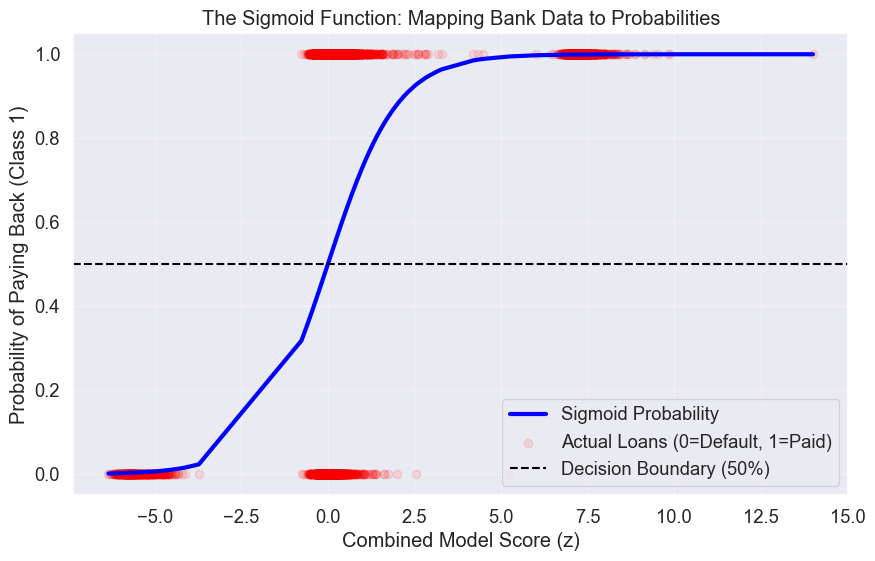

In [187]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Calculate the 'Score' (z) for every loan in your test set
# This is the internal value before the sigmoid is applied
z = model.decision_function(X_test)

# 2. Get the probability of '1' (Paid) from the model
probabilities = model.predict_proba(X_test)[:, 1]

# 3. Sort the values so the line draws smoothly from left to right
sort_idx = np.argsort(z)
z_sorted = z[sort_idx]
prob_sorted = probabilities[sort_idx]

# 4. Create the Visualization
plt.figure(figsize=(10, 6))

# Plot the beautiful S-curve (the Sigmoid)
plt.plot(z_sorted, prob_sorted, color='blue', linewidth=3, label='Sigmoid Probability')

# Add the actual outcomes (0 or 1) as dots
# We use alpha=0.1 to see where the data is most "dense"
plt.scatter(z, y_test, color='red', alpha=0.1, label='Actual Loans (0=Default, 1=Paid)')

# Add a dashed line at the 0.5 threshold
plt.axhline(0.5, color='black', linestyle='--', label='Decision Boundary (50%)')

plt.title('The Sigmoid Function: Mapping Bank Data to Probabilities')
plt.xlabel('Combined Model Score (z)')
plt.ylabel('Probability of Paying Back (Class 1)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

This sigmoid plot visualizes how the model converts complex borrower data into a single probability score to determine loan risk.The blue S-curve represents the mathematical heart of the model; it maps the "Combined Model Score" on the horizontal axis to a probability between $0$ and $1$ on the vertical axis. When a borrower’s score falls to the left of the center (below the 0.5 dashed line), the model classifies them as a high-risk "Default," whereas scores to the right are classified as "Fully Paid."The red dots represent the actual outcomes from your test data, and their heavy concentration at the top-right and bottom-left extremes shows that the model is highly confident and accurate when dealing with very strong or very weak applicants. The overlap in the middle—where red dots appear on the "wrong" side of the curve—illustrates the 33% error rate where the model's prediction didn't match the final outcome, highlighting the inherent difficulty in predicting human financial behavior.

CONCLUSION:-
The final Logistic Regression model achieved an overall accuracy of 67%, but its true value lies in its ability to manage financial risk. While the accuracy decreased compared to the initial model, we successfully increased the Recall for defaults to 60%, meaning the bank can now proactively identify and stop 6 out of every 10 potentially bad loans before they occur.

This model represents a strategic shift from simply guessing the most common outcome to actively protecting the bank's capital. Although the Precision for risky loans is 34%—resulting in some safe customers being flagged for extra review—this conservative approach is financially safer than the previous model, which missed 76% of all defaults.

In summary, this model provides a balanced framework that prioritizes the detection of high-risk borrowers, offering a significant improvement in the bank's ability to mitigate losses compared to a standard, imbalanced approach.